<a href="https://colab.research.google.com/github/mfernandasoni/RappiPlus_from_data_to_business_decisions/blob/main/RappiPlus_de_datos_a_decisiones_negocio_MFSC_EN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RappiPlus Project: from data to business decisions

**Introduction**


The objective of this project is to evaluate the performance of the **RappiPlus** service to support **data-driven business decisions**.

Multiple business datasets are used:

- **rappiplus_orders_raw.csv** → order, pricing, discount, and revenue information  
- **rappiplus_catalog.csv** → product costs, categories, and suppliers  
- **rappiplus_marketing_spend.csv** → marketing investment by channel and country  
- **events / users / user_activity (SQL)** → user behavior within the platform  
- **experiment_checkout_ui.csv** → results of an A/B experiment in checkout  

The analysis follows a clear, progressive logic:

1. 🔍 Assess whether we can trust the data (data quality in Python)

2. 💰 Analyze whether the business is profitable (revenue, costs, and profit)  

3. 🛒 Understand where users are lost (conversion funnel)  

4. 🔁 Assess whether users come back (cohort retention)  

5. 🧪 Validate whether changes generate impact (statistical test)  

6. 📊 Communicate the results (BI dashboard)  

Throughout the project, data is turned into insights to answer key business questions and propose **actionable recommendations**.

---

## 🔹 Step 1: Load and validate data quality

---

### 1.1 Data loading and quick look

**🎯 Objective:** Get familiar with the structure of the business datasets before analyzing them.

In [1]:
# import libraries
import pandas as pd
import numpy as np

In [2]:
# load files
orders = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_orders_raw.csv')
catalog =pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_catalog.csv')
marketing = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_marketing_spend.csv')

In [3]:
# explore datasets
orders.info()
orders.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25100 non-null  object 
 1   id_usuario          25100 non-null  object 
 2   fecha_hora_pedido   25100 non-null  object 
 3   pais                24800 non-null  object 
 4   dispositivo         25080 non-null  object 
 5   fuente_referencia   25070 non-null  object 
 6   nombre_producto     25070 non-null  object 
 7   categoria_producto  25020 non-null  object 
 8   cantidad            25050 non-null  float64
 9   precio_unitario     25050 non-null  float64
 10  monto_descuento     25050 non-null  float64
 11  monto_total         25100 non-null  float64
dtypes: float64(4), object(8)
memory usage: 2.3+ MB


,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.37
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86
2,order_2,user_3194,2025-05-02,Argentina,desktop,social,Blender-XL-Red,Hogar,2.0,102.99,10.0,195.99
3,order_3,user_4510,2025-06-09,Colombia,mobile,social,Tablet-Standard-64GB,Electronica,1.0,257.87,15.0,242.87
4,order_4,user_5044,2025-03-30,Argentina,desktop,paid_search,Blender-XL-Red,Hogar,1.0,336.28,0.0,336.28


In [4]:
catalog.info()
catalog.head(7)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nombre_producto     7 non-null      object 
 1   categoria_producto  7 non-null      object 
 2   costo_unitario      7 non-null      float64
 3   proveedor           7 non-null      object 
dtypes: float64(1), object(3)
memory usage: 356.0+ bytes


,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electrónica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electrónica,10.12,King Ltd
2,Tablet-Standard-64GB,Electrónica,25.21,Bowers LLC
3,Blender-XL-Red,Hogar,176.64,Long-Reid
4,Vacuum-Pro-Black,Hogar,16.60,"Rivera, Carr and Finley"
5,Sneakers-Urban-42,Moda,17.21,Greene-Smith
6,Jacket-Winter-M,Moda,189.31,Mcmillan-Rhodes


In [5]:
marketing.info()
marketing.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fecha       1620 non-null   object 
 1   pais        1620 non-null   object 
 2   id_campaña  1620 non-null   object 
 3   canal       1519 non-null   object 
 4   gasto       1620 non-null   float64
dtypes: float64(1), object(4)
memory usage: 63.4+ KB


,fecha,pais,id_campaña,canal,gasto
0,2025-01-01,Mexico,organic_Mexico,organic,2446.25
1,2025-01-01,Mexico,paid_search_Mexico,paid_search,2704.34
2,2025-01-01,Mexico,social_Mexico,social,2045.01
3,2025-01-01,Colombia,organic_Colombia,organic,2597.21
4,2025-01-01,Colombia,paid_search_Colombia,paid_search,1771.40


---

### Data review and quality

**🎯 Objective:** Detect and fix data issues that could affect the revenue, cost, and profitability analysis.


#### 1. Validate and convert dates to the correct format

In [6]:
# Convert the orders and marketing date columns to date type with pd.to_datetime()
orders['fecha_hora_pedido']= pd.to_datetime(orders['fecha_hora_pedido'], errors="coerce")
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_pedido           25100 non-null  object        
 1   id_usuario          25100 non-null  object        
 2   fecha_hora_pedido   25100 non-null  datetime64[ns]
 3   pais                24800 non-null  object        
 4   dispositivo         25080 non-null  object        
 5   fuente_referencia   25070 non-null  object        
 6   nombre_producto     25070 non-null  object        
 7   categoria_producto  25020 non-null  object        
 8   cantidad            25050 non-null  float64       
 9   precio_unitario     25050 non-null  float64       
 10  monto_descuento     25050 non-null  float64       
 11  monto_total         25100 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(7)
memory usage: 2.3+ MB


In [7]:
marketing['fecha']=pd.to_datetime(marketing['fecha'],errors="coerce")
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   fecha       1620 non-null   datetime64[ns]
 1   pais        1620 non-null   object        
 2   id_campaña  1620 non-null   object        
 3   canal       1519 non-null   object        
 4   gasto       1620 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 63.4+ KB


#### 2. Review numeric variables (no negatives or invalid zeros)

In [8]:
#Review the orders dataset
orders.describe()

,fecha_hora_pedido,cantidad,precio_unitario,monto_descuento,monto_total
count,25100,25050.000000,25050.000000,25050.000000,2.510000e+04
mean,2025-04-01 03:21:22.231075584,7.092735,259.305549,4.500798,2.072680e+03
min,2025-01-01 00:00:00,-2.000000,20.030000,0.000000,-4.926500e+02
25%,2025-02-15 00:00:00,1.000000,138.377500,0.000000,1.805075e+02
50%,2025-04-02 00:00:00,2.000000,258.715000,0.000000,3.417500e+02
75%,2025-05-16 00:00:00,2.000000,380.332500,10.000000,5.185800e+02
max,2025-06-30 00:00:00,20000.000000,499.960000,15.000000,8.840200e+06
std,NaN,296.277003,138.726461,5.223010,9.894995e+04


**Reflection:** The numeric variables were reviewed using descriptive statistics; *precio_unitario* and *monto_descuento* did not show values outside logically impossible ranges. However, anomalous values were detected in *cantidad*, including negative values and extremely high quantities. These records also produce negative or exceptionally high values in *monto_total*.

In [9]:
#Calculate nulls, invalid zeros, and negatives
num_cols_orders=["cantidad", "precio_unitario", "monto_descuento", "monto_total"]
n_total_orders=len(orders)
resumen_orders=[]

for col in num_cols_orders:
    n_neg = (orders[col] < 0).sum()
    n_zero = (orders[col] == 0).sum()
    n_null = orders[col].isna().sum()
    resumen_orders.append({
        "columna": col,
        "negativos": n_neg,
        "% negativos": round(n_neg / n_total_orders * 100, 2),
        "ceros": n_zero,
        "% ceros": round(n_zero / n_total_orders * 100, 2),
        "nulos": n_null,
        "% nulos": round(n_null / n_total_orders * 100, 2),
    })

pd.DataFrame(resumen_orders)

,columna,negativos,% negativos,ceros,% ceros,nulos,% nulos
0,cantidad,4,0.02,0,0.0,50,0.2
1,precio_unitario,0,0.00,0,0.0,50,0.2
2,monto_descuento,0,0.00,12551,50.0,50,0.2
3,monto_total,4,0.02,0,0.0,0,0.0


In [10]:
#Identify the outliers
print("Quantity greater than 100:", (orders["cantidad"] > 100).sum())
print("Total amount greater than 100,000:", (orders["monto_total"] > 100000).sum())

Quantity greater than 100: 10
Total amount greater than 100,000: 10


In [11]:
#Explore the outliers
orders_outliers= orders[orders["cantidad"]>100]
orders_outliers

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
3521,order_3521,user_5812,2025-02-03,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electronica,10000.0,43.14,0.0,431400.0
3522,order_3522,user_3575,2025-03-29,Argentina,desktop,social,Laptop-Gaming-16GB,Electronica,10000.0,280.55,0.0,2805500.0
3586,order_3586,user_3380,2025-02-03,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electronica,10000.0,490.35,0.0,4903500.0
3643,order_3643,user_4440,2025-01-07,Colombia,desktop,social,Laptop-Gaming-16GB,Electronica,10000.0,238.15,0.0,2381500.0
3656,order_3656,user_884,2025-01-01,Argentina,mobile,organic,Laptop-Gaming-16GB,Electronica,20000.0,297.66,0.0,5953200.0
3668,order_3668,user_7270,2025-06-24,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electronica,20000.0,348.31,0.0,6966200.0
3689,order_3689,user_6566,2025-06-16,mexico,desktop,paid_search,Laptop-Gaming-16GB,Electronica,10000.0,87.69,0.0,876900.0
3722,order_3722,user_4723,2025-05-09,Argentina,mobile,paid_search,Laptop-Gaming-16GB,Electronica,20000.0,442.01,0.0,8840200.0
3726,order_3726,user_2536,2025-02-12,Colombia,desktop,social,Laptop-Gaming-16GB,Electronica,20000.0,290.85,0.0,5817000.0
3748,order_3748,user_7096,2025-02-23,Mexico,desktop,organic,Laptop-Gaming-16GB,Electronica,10000.0,336.93,0.0,3369300.0


**Reflection:**

10 records (0.04% of total orders) were identified with a requested quantity of 10,000 or 20,000 units, far above the rest of the dataset (median of 2 units per line). Unlike random variation, these values are exact and round, and share one common trait: all correspond to the Laptop-Gaming-16GB product, although they involve 10 different users, with no overlap in date, device, referral source, or country. The unit price on these records does vary within a normal range, so the inconsistency is concentrated solely in the quantity field.

Since there is no additional information available (e.g., a unit-conversion record or a bulk-order flag) that would confirm whether this quantity is valid or the result of a capture or system error, it was decided not to modify or remove the original data, preserving the integrity of the raw source.

However, these 10 records can influence the KPI calculations, so they will be excluded from the main KPI analysis and evaluated separately.

In [12]:
#Review the catalog dataset
catalog.describe()

,costo_unitario
count,7.000000
mean,102.252857
std,111.011563
min,10.120000
25%,16.905000
50%,25.210000
75%,182.975000
max,280.680000


**Reflection:** No negative or zero values were detected in *costo_unitario*. Costs range between 10.12 and 280.68, so no logically impossible values were identified. The variability observed across products is expected and does not by itself represent a data quality issue.

In [13]:
#Review the marketing dataset
marketing.describe()

,fecha,gasto
count,1620,1620.00000
mean,2025-03-31 12:00:00,1772.74292
min,2025-01-01 00:00:00,501.11000
25%,2025-02-14 18:00:00,1128.03000
50%,2025-03-31 12:00:00,1782.42500
75%,2025-05-15 06:00:00,2420.68500
max,2025-06-29 00:00:00,2999.36000
std,NaN,734.43294


**Reflection:** Descriptive statistics for *gasto* were reviewed and no negative or zero values were identified. Spend ranges between 501.11 and 2,999.36, with no logically impossible values. The variability observed is considered reasonable across different marketing campaigns.

#### 3. Verify amount consistency

In [14]:
# expected_amount = quantity * unit_price - discount
# The sign is preserved for negative transactions
# 1-cent tolerance for rounding

orders["monto_esperado"] = (
    np.sign(orders["cantidad"]) *
    (
        orders["cantidad"].abs() * orders["precio_unitario"]
        - orders["monto_descuento"]
    )
)

orders["diferencia"] = (
    orders["monto_total"] - orders["monto_esperado"]
).abs()

orders["es_coherente"] = orders["diferencia"] <= 0.01

print("\n=== Amount consistency ===")

print(
    f"Consistent:   {orders['es_coherente'].sum()} "
    f"({orders['es_coherente'].mean()*100:.2f}%)"
)

print(
    f"Inconsistent: {(~orders['es_coherente']).sum()} "
    f"({(~orders['es_coherente']).mean()*100:.2f}%)"
)


=== Amount consistency ===
Consistent:   23904 (95.24%)
Inconsistent: 1196 (4.76%)


In [15]:
orders[
    ~orders["es_coherente"]
][
    [
        "cantidad",
        "precio_unitario",
        "monto_descuento",
        "monto_total",
        "monto_esperado",
        "diferencia"
    ]
].head(20)


,cantidad,precio_unitario,monto_descuento,monto_total,monto_esperado,diferencia
2,2.0,102.99,10.0,195.99,195.98,0.01
24,2.0,117.99,0.0,235.99,235.98,0.01
35,2.0,467.34,5.0,929.69,929.68,0.01
41,2.0,37.77,10.0,65.53,65.54,0.01
74,NaN,NaN,NaN,595.85,NaN,NaN
75,NaN,NaN,NaN,458.15,NaN,NaN
76,NaN,NaN,NaN,319.75,NaN,NaN
77,NaN,NaN,NaN,227.55,NaN,NaN
78,NaN,NaN,NaN,432.39,NaN,NaN
79,NaN,NaN,NaN,527.15,NaN,NaN


In [16]:
# Identify whether data needed to calculate the expected amount is missing
orders["datos_monto_completos"] = orders[
    ["cantidad", "precio_unitario", "monto_descuento", "monto_total"]
].notna().all(axis=1)

# Classification
orders["consistencia_monto"] = np.select(
    [
        ~orders["datos_monto_completos"],
        orders["diferencia"] <= 0.01
    ],
    [
        "Not verifiable - missing data",
        "Consistent"
    ],
    default="Inconsistent"
)

resumen = orders["consistencia_monto"].value_counts()

total = len(orders)

print("\n=== Amount consistency ===")

for categoria, cantidad in resumen.items():
    porcentaje = cantidad / total * 100
    print(f"{categoria}: {cantidad} ({porcentaje:.2f}%)")

print(f"\nTotal records: {total}")



=== Amount consistency ===
Consistent: 23904 (95.24%)
Inconsistent: 1146 (4.57%)
Not verifiable - missing data: 50 (0.20%)

Total records: 25100


In [17]:
orders[orders["consistencia_monto"] == "Inconsistente"]["diferencia"].describe()

,diferencia
count,0.0
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN


**Reflection:** **95.25%** of orders show **arithmetic consistency** between quantity, unit price, discount, and total amount. **4.55%** show a **$0.01 difference**, preliminarily attributable to **rounding**. The remaining **0.20% could not be verified due to missing data.**

#### 4. Null Values and Duplicates

In [18]:
#Diagnosis by Dataset of null values and duplicates

datasets = {
    "Orders": orders,
    "Catalog": catalog,
    "Marketing": marketing
}

for nombre, df in datasets.items():

    print("\n" + "=" * 60)
    print(f"DATASET: {nombre}")
    print("=" * 60)

    # Null values
    print("\n--- Null values ---")

    nulos = df.isna().sum()
    porcentaje_nulos = (nulos / len(df) * 100).round(2)

    resumen_nulos = pd.DataFrame({
        "nulos": nulos,
        "porcentaje": porcentaje_nulos
    })


    print(resumen_nulos[resumen_nulos["nulos"] > 0])

    # Duplicates
    print("\n--- Duplicates ---")
    duplicados = df.duplicated().sum()
    porcentaje_duplicados = duplicados / len(df) * 100

    print(
        f"Duplicates: {duplicados:,} "
        f"({porcentaje_duplicados:.2f}%)"
    )


DATASET: Orders

--- Null values ---
                    nulos  porcentaje
pais                  300        1.20
dispositivo            20        0.08
fuente_referencia      30        0.12
nombre_producto        30        0.12
categoria_producto     80        0.32
cantidad               50        0.20
precio_unitario        50        0.20
monto_descuento        50        0.20
monto_esperado         50        0.20
diferencia             50        0.20

--- Duplicates ---
Duplicates: 100 (0.40%)

DATASET: Catalog

--- Null values ---
Empty DataFrame
Columns: [nulos, porcentaje]
Index: []

--- Duplicates ---
Duplicates: 0 (0.00%)

DATASET: Marketing

--- Null values ---
       nulos  porcentaje
canal    101        6.23

--- Duplicates ---
Duplicates: 0 (0.00%)


**Orders Dataset**

In [19]:
# How many id_pedido are duplicated?
orders["id_pedido"].duplicated().sum()

np.int64(100)

In [20]:
# Show the fully duplicated rows
orders[orders.duplicated(keep=False)].sort_values("id_pedido")

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total,monto_esperado,diferencia,es_coherente,datos_monto_completos,consistencia_monto
25023,order_10082,user_690,2025-02-17,Argentina,desktop,social,Sneakers-Urban-42,Moda,2.0,221.34,0.0,442.67,442.68,0.01,True,True,Consistent
10082,order_10082,user_690,2025-02-17,Argentina,desktop,social,Sneakers-Urban-42,Moda,2.0,221.34,0.0,442.67,442.68,0.01,True,True,Consistent
25037,order_10709,user_6783,2025-02-16,Colombia,mobile,organic,Jacket-Winter-M,Moda,1.0,170.10,10.0,160.10,160.10,0.00,True,True,Consistent
10709,order_10709,user_6783,2025-02-16,Colombia,mobile,organic,Jacket-Winter-M,Moda,1.0,170.10,10.0,160.10,160.10,0.00,True,True,Consistent
25065,order_10829,user_7697,2025-01-23,Argentina,mobile,social,Phone-Pro-128GB,Electronica,2.0,115.54,0.0,231.08,231.08,0.00,True,True,Consistent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25048,order_8326,user_6177,2025-06-14,Argentina,mobile,organic,Vacuum-Pro-Black,Hogar,1.0,457.53,0.0,457.53,457.53,0.00,True,True,Consistent
25043,order_8414,user_4073,2025-05-10,Colombia,mobile,social,Jacket-Winter-M,Moda,2.0,144.35,10.0,278.71,278.70,0.01,True,True,Consistent
8414,order_8414,user_4073,2025-05-10,Colombia,mobile,social,Jacket-Winter-M,Moda,2.0,144.35,10.0,278.71,278.70,0.01,True,True,Consistent
25056,order_974,user_3262,2025-05-04,Argentina,desktop,paid_search,Blender-XL-Red,Hogar,2.0,268.58,5.0,532.16,532.16,0.00,True,True,Consistent


In [21]:
#Remove duplicates from "Orders" and validate
orders = orders.drop_duplicates(subset="id_pedido", keep="first").reset_index(drop=True)
print(f"Duplicates in Orders:", orders.duplicated(subset="id_pedido").sum())

Duplicates in Orders: 0


**Reflection:** 100 duplicate records were identified in *Orders*, corresponding to orders with a repeated id_pedido and fully identical records. A single instance of each order was kept, resulting in 25,000 unique records.

In [22]:
#Rows where cantidad is a null value
orders[orders['cantidad'].isna()]

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total,monto_esperado,diferencia,es_coherente,datos_monto_completos,consistencia_monto
74,order_74,user_6172,2025-01-15,Argentina,desktop,organic,Sneakers-Urban-42,NaN,NaN,NaN,NaN,595.85,NaN,NaN,False,False,Not verifiable - missing data
75,order_75,user_6588,2025-06-19,Colombia,mobile,organic,Sneakers-Urban-42,NaN,NaN,NaN,NaN,458.15,NaN,NaN,False,False,Not verifiable - missing data
76,order_76,user_3193,2025-03-17,Argentina,mobile,paid_search,Laptop-Gaming-16GB,NaN,NaN,NaN,NaN,319.75,NaN,NaN,False,False,Not verifiable - missing data
77,order_77,user_775,2025-06-24,Argentina,desktop,social,Vacuum-Pro-Black,NaN,NaN,NaN,NaN,227.55,NaN,NaN,False,False,Not verifiable - missing data
78,order_78,user_2702,2025-03-19,Argentina,desktop,paid_search,Phone-Pro-128GB,NaN,NaN,NaN,NaN,432.39,NaN,NaN,False,False,Not verifiable - missing data
79,order_79,user_6438,2025-03-22,Colombia,desktop,paid_search,Sneakers-Urban-42,NaN,NaN,NaN,NaN,527.15,NaN,NaN,False,False,Not verifiable - missing data
80,order_80,user_6790,2025-01-03,Mexico,desktop,organic,Vacuum-Pro-Black,NaN,NaN,NaN,NaN,711.18,NaN,NaN,False,False,Not verifiable - missing data
81,order_81,user_232,2025-05-16,Mexico,mobile,paid_search,Tablet-Standard-64GB,NaN,NaN,NaN,NaN,41.08,NaN,NaN,False,False,Not verifiable - missing data
82,order_82,user_5665,2025-02-07,Colombia,mobile,paid_search,Sneakers-Urban-42,NaN,NaN,NaN,NaN,431.55,NaN,NaN,False,False,Not verifiable - missing data
83,order_83,user_5225,2025-04-25,Argentina,mobile,organic,Sneakers-Urban-42,NaN,NaN,NaN,NaN,279.35,NaN,NaN,False,False,Not verifiable - missing data


**Reflection:** It is observed that the 50 records with null values in the *cantidad* column are the same ones for the *precio_unitario* and *monto_descuento* columns. In addition, the *categoria_producto* column is also empty for these records.

There isn't enough information in the other variables to reliably recover *cantidad*, *precio_unitario*, and *monto_descuento* for these products, so they are kept as null values to avoid arbitrary imputations that could affect the sales analysis.

The *categoria_producto* column can be recovered using information from *Catalog*.

In [23]:
#Merge Orders and Catalog
orders = pd.merge(orders, catalog,
    on="nombre_producto",
    how="left",
    suffixes=("", "_catalog"))
#orders[orders['cantidad'].isna()]
orders.head()

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total,monto_esperado,diferencia,es_coherente,datos_monto_completos,consistencia_monto,categoria_producto_catalog,costo_unitario,proveedor
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.37,665.38,0.01,True,True,Consistent,Moda,189.31,Mcmillan-Rhodes
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86,171.86,0.00,True,True,Consistent,Electrónica,25.21,Bowers LLC
2,order_2,user_3194,2025-05-02,Argentina,desktop,social,Blender-XL-Red,Hogar,2.0,102.99,10.0,195.99,195.98,0.01,False,True,Inconsistent,Hogar,176.64,Long-Reid
3,order_3,user_4510,2025-06-09,Colombia,mobile,social,Tablet-Standard-64GB,Electronica,1.0,257.87,15.0,242.87,242.87,0.00,True,True,Consistent,Electrónica,25.21,Bowers LLC
4,order_4,user_5044,2025-03-30,Argentina,desktop,paid_search,Blender-XL-Red,Hogar,1.0,336.28,0.0,336.28,336.28,0.00,True,True,Consistent,Hogar,176.64,Long-Reid


In [24]:
#Fill categoria_producto with the category from catalog
orders["categoria_producto"]=orders["categoria_producto"].fillna(orders["categoria_producto_catalog"])
orders[orders['cantidad'].isna()].head()

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total,monto_esperado,diferencia,es_coherente,datos_monto_completos,consistencia_monto,categoria_producto_catalog,costo_unitario,proveedor
74,order_74,user_6172,2025-01-15,Argentina,desktop,organic,Sneakers-Urban-42,Moda,NaN,NaN,NaN,595.85,NaN,NaN,False,False,Not verifiable - missing data,Moda,17.21,Greene-Smith
75,order_75,user_6588,2025-06-19,Colombia,mobile,organic,Sneakers-Urban-42,Moda,NaN,NaN,NaN,458.15,NaN,NaN,False,False,Not verifiable - missing data,Moda,17.21,Greene-Smith
76,order_76,user_3193,2025-03-17,Argentina,mobile,paid_search,Laptop-Gaming-16GB,Electrónica,NaN,NaN,NaN,319.75,NaN,NaN,False,False,Not verifiable - missing data,Electrónica,280.68,"Fuller, Pena and Myers"
77,order_77,user_775,2025-06-24,Argentina,desktop,social,Vacuum-Pro-Black,Hogar,NaN,NaN,NaN,227.55,NaN,NaN,False,False,Not verifiable - missing data,Hogar,16.60,"Rivera, Carr and Finley"
78,order_78,user_2702,2025-03-19,Argentina,desktop,paid_search,Phone-Pro-128GB,Electrónica,NaN,NaN,NaN,432.39,NaN,NaN,False,False,Not verifiable - missing data,Electrónica,10.12,King Ltd


In [25]:
# Review the 30 records where the category is still missing
orders[orders["categoria_producto"].isna()][[
    "id_pedido",
    "fuente_referencia",
    "nombre_producto",
    "precio_unitario",
    "cantidad",
    "monto_total"
]]

,id_pedido,fuente_referencia,nombre_producto,precio_unitario,cantidad,monto_total
44,order_44,NaN,NaN,318.38,1.0,313.38
45,order_45,NaN,NaN,354.06,2.0,698.12
46,order_46,NaN,NaN,359.31,1.0,349.31
47,order_47,NaN,NaN,476.78,2.0,953.56
48,order_48,NaN,NaN,137.96,2.0,275.93
49,order_49,NaN,NaN,433.76,2.0,867.53
50,order_50,NaN,NaN,495.38,1.0,490.38
51,order_51,NaN,NaN,382.94,2.0,765.89
52,order_52,NaN,NaN,415.01,2.0,830.01
53,order_53,NaN,NaN,236.49,2.0,472.98


**Reflection:** It is observed that in the 30 records where *categoria_producto* is missing, *fuente_referencia* and *nombre_producto* are also missing. These records cannot be recovered with any additional dataset. In this case, they will be filled as "Unknown" so as not to influence the analysis and to make later visualization easier.

In [26]:
#Fill null values with "Unknown"
orders["nombre_producto"] = (
    orders["nombre_producto"].fillna("Desconocido")
)

orders["categoria_producto"] = (
    orders["categoria_producto"].fillna("Desconocido")
)

orders["fuente_referencia"] = (
    orders["fuente_referencia"].fillna("Desconocido")
)

orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   id_pedido                   25000 non-null  object        
 1   id_usuario                  25000 non-null  object        
 2   fecha_hora_pedido           25000 non-null  datetime64[ns]
 3   pais                        24700 non-null  object        
 4   dispositivo                 24980 non-null  object        
 5   fuente_referencia           25000 non-null  object        
 6   nombre_producto             25000 non-null  object        
 7   categoria_producto          25000 non-null  object        
 8   cantidad                    24950 non-null  float64       
 9   precio_unitario             24950 non-null  float64       
 10  monto_descuento             24950 non-null  float64       
 11  monto_total                 25000 non-null  float64   

In [27]:
#Handle null values in Dispositivo
orders["dispositivo"] = orders["dispositivo"].fillna("Desconocido")
orders["dispositivo"].value_counts(dropna=False)


,count
dispositivo,
desktop,12711
mobile,12269
Desconocido,20


**Reflection:** Null values are filled with "Unknown" so they can be identified later in the dashboard.

In [28]:
#Handle null values in Pais
orders["pais"].value_counts()


,count
pais,
Colombia,7481
Mexico,7478
Argentina,7259
mexico,863
colombia,823
argentina,796


**Comment:** Inconsistencies are detected in the country values. This column needs to be normalized.

In [29]:
#Normalize the pais column
orders["pais"] = orders["pais"].str.strip().str.title()
orders["pais"].value_counts(dropna=False)

,count
pais,
Mexico,8341
Colombia,8304
Argentina,8055
NaN,300


In [30]:
#Number of unique users
orders["id_usuario"].nunique()

7642

In [31]:
#Create a new table relating id_usuario to pais
usuarios_pais = orders[
    orders["pais"].notna()
][["id_usuario", "pais"]].drop_duplicates()

#Check how many countries exist per user
usuarios_pais.groupby("id_usuario")["pais"].nunique().value_counts()

,count
pais,
1,7624


**Comment:** 7,642 unique users were identified. Of these, 7,624 have country information, and each user is associated with a single country. The remaining 18 users have no country information available in their records.

In [32]:
#View the id_usuario–pais relationship
usuarios_pais_serie = usuarios_pais.set_index("id_usuario")["pais"]
usuarios_pais_serie

,pais
id_usuario,
user_6993,Argentina
user_1329,Mexico
user_3194,Argentina
user_4510,Colombia
user_5044,Argentina
...,...
user_1231,Colombia
user_4569,Argentina
user_7965,Argentina


In [33]:
#Impute countries for rows where it's missing
pais_faltante = orders["pais"].isna()

orders.loc[pais_faltante, "pais"] = (
    orders.loc[pais_faltante, "id_usuario"]
    .map(usuarios_pais_serie)
)

#Check how many null values remain in Pais
nulos_antes = 300
nulos_despues = orders["pais"].isna().sum()

recuperados = nulos_antes - nulos_despues

print(f"Countries recovered: {recuperados}")
print(f"Countries still missing: {nulos_despues}")

Countries recovered: 281
Countries still missing: 19


In [34]:
#Whatever can't be recovered is set as "Unknown"
orders["pais"] = orders["pais"].fillna("Desconocido")

#Check unique values of the pais column
orders["pais"].value_counts()


,count
pais,
Mexico,8440
Colombia,8386
Argentina,8155
Desconocido,19


**Reflection:** 300 records with a missing country were identified. Since 7,624 users have a single registered country, it was possible to recover the country of the missing orders using the user's history. Records corresponding to users with no historical country information were classified as "Unknown".

In [35]:
#Reduce the dataset to the columns needed for the analysis
orders_clean = orders.drop(columns=[
    "monto_esperado",
    "diferencia",
    "categoria_producto_catalog",
    "costo_unitario",
    "proveedor"
])

orders_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id_pedido              25000 non-null  object        
 1   id_usuario             25000 non-null  object        
 2   fecha_hora_pedido      25000 non-null  datetime64[ns]
 3   pais                   25000 non-null  object        
 4   dispositivo            25000 non-null  object        
 5   fuente_referencia      25000 non-null  object        
 6   nombre_producto        25000 non-null  object        
 7   categoria_producto     25000 non-null  object        
 8   cantidad               24950 non-null  float64       
 9   precio_unitario        24950 non-null  float64       
 10  monto_descuento        24950 non-null  float64       
 11  monto_total            25000 non-null  float64       
 12  es_coherente           25000 non-null  bool          
 13  d

**Marketing Dataset**

In [36]:
marketing[marketing["canal"].isna()]

,fecha,pais,id_campaña,canal,gasto
98,2025-01-11,Argentina,social_Argentina,NaN,849.70
99,2025-01-12,Mexico,organic_Mexico,NaN,2033.56
100,2025-01-12,Mexico,paid_search_Mexico,NaN,1260.65
101,2025-01-12,Mexico,social_Mexico,NaN,1660.90
102,2025-01-12,Colombia,organic_Colombia,NaN,1819.27
...,...,...,...,...,...
194,2025-01-22,Colombia,social_Colombia,NaN,772.46
195,2025-01-22,Argentina,organic_Argentina,NaN,1562.61
196,2025-01-22,Argentina,paid_search_Argentina,NaN,644.34
197,2025-01-22,Argentina,social_Argentina,NaN,2544.66


In [37]:
#Extract the channel from each id_campaña
marketing["canal_recuperado"] = marketing["id_campaña"].str.extract(
    r"^(social|organic|paid_search)"
)
marketing["canal_recuperado"]

,canal_recuperado
0,organic
1,paid_search
2,social
3,organic
4,paid_search
...,...
1615,paid_search
1616,social
1617,organic
1618,paid_search


In [38]:
#Use that value only where canal is empty
marketing["canal"] = marketing["canal"].fillna(
    marketing["canal_recuperado"]
)

#Check nulls in canal
marketing["canal"].isna().sum()


np.int64(0)

In [39]:
#Check the values for each channel type
marketing["canal"].value_counts()

,count
canal,
organic,540
paid_search,540
social,540


In [40]:
#Remove the auxiliary column
marketing = marketing.drop(columns=["canal_recuperado"])
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   fecha       1620 non-null   datetime64[ns]
 1   pais        1620 non-null   object        
 2   id_campaña  1620 non-null   object        
 3   canal       1620 non-null   object        
 4   gasto       1620 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 63.4+ KB


**Reflection:** 101 records with a missing channel were identified. The channel could be recovered from id_campaña, since this variable explicitly contains the campaign type (social, organic, and paid_search). This relationship was used to fill in the missing values without arbitrary imputation.

#### 5. Review categorical variables

**Orders_clean Dataset**

In [41]:
orders_clean.nunique()

,0
id_pedido,25000
id_usuario,7642
fecha_hora_pedido,181
pais,4
dispositivo,3
fuente_referencia,4
nombre_producto,8
categoria_producto,5
cantidad,6
precio_unitario,19543


In [42]:

#Review the pais variable
orders_clean['pais'].value_counts()


,count
pais,
Mexico,8440
Colombia,8386
Argentina,8155
Desconocido,19


In [43]:
#Review the dispositivo variable
orders_clean['dispositivo'].value_counts()

,count
dispositivo,
desktop,12711
mobile,12269
Desconocido,20


In [44]:
#Review the fuente_referencia variable
orders_clean['fuente_referencia'].value_counts()

,count
fuente_referencia,
social,8402
organic,8288
paid_search,8280
Desconocido,30


In [45]:

#Review the nombre_producto variable
orders_clean['nombre_producto'].value_counts()


,count
nombre_producto,
Blender-XL-Red,4179
Jacket-Winter-M,4176
Vacuum-Pro-Black,4176
Sneakers-Urban-42,4148
Laptop-Gaming-16GB,2782
Tablet-Standard-64GB,2769
Phone-Pro-128GB,2740
Desconocido,30


In [46]:
#Review the categoria_producto variable
orders_clean['categoria_producto'].value_counts()

,count
categoria_producto,
Hogar,8355
Moda,8324
Electronica,8279
Desconocido,30
Electrónica,12


In [47]:
#Normalize the categoria_producto variable
orders_clean["categoria_producto"] = orders_clean["categoria_producto"].replace(
    "Electronica",
    "Electrónica"
)

#Validate normalization
orders_clean["categoria_producto"].value_counts()

,count
categoria_producto,
Hogar,8355
Moda,8324
Electrónica,8291
Desconocido,30


**Reflection:** A spelling inconsistency was detected in the *categoria_producto* variable: the categories Electronica and Electrónica represent the same category and only differ by the accent mark. Both values were consolidated under Electrónica. The 30 records classified as Unknown were kept, since it wasn't possible to identify their category from the available information.

**Catalog Dataset**

In [48]:
#Review the nombre_producto variable
catalog["nombre_producto"].value_counts()

,count
nombre_producto,
Laptop-Gaming-16GB,1
Phone-Pro-128GB,1
Tablet-Standard-64GB,1
Blender-XL-Red,1
Vacuum-Pro-Black,1
Sneakers-Urban-42,1
Jacket-Winter-M,1


In [49]:
#Review the categoria_producto variable
catalog["categoria_producto"].value_counts()

,count
categoria_producto,
Electrónica,3
Hogar,2
Moda,2


In [50]:
#Review the proveedor variable
catalog["proveedor"].value_counts()

,count
proveedor,
"Fuller, Pena and Myers",1
King Ltd,1
Bowers LLC,1
Long-Reid,1
"Rivera, Carr and Finley",1
Greene-Smith,1
Mcmillan-Rhodes,1


**Reflection:** Categorical variables in the *catalog* dataset are normalized and clean.

**Marketing Dataset**

In [51]:
#Review the pais variable
marketing["pais"].value_counts()


,count
pais,
Mexico,540
Colombia,540
Argentina,540


In [52]:
#Review the id_campaña variable
marketing["id_campaña"].value_counts()

,count
id_campaña,
organic_Mexico,180
paid_search_Mexico,180
social_Mexico,180
organic_Colombia,180
paid_search_Colombia,180
social_Colombia,180
organic_Argentina,180
paid_search_Argentina,180
social_Argentina,180


In [53]:
#Review the canal variable
marketing["canal"].value_counts(dropna=False)

,count
canal,
organic,540
paid_search,540
social,540


In [54]:
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   fecha       1620 non-null   datetime64[ns]
 1   pais        1620 non-null   object        
 2   id_campaña  1620 non-null   object        
 3   canal       1620 non-null   object        
 4   gasto       1620 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 63.4+ KB


**Reflection:** Categorical variables in the *marketing* dataset are normalized and clean.

**Cleaning conclusion:** A cleaning and validation process was carried out on the *orders*, *catalog*, and *marketing* datasets, including review of null values, duplicates, data types, categorical variables, impossible values, amount consistency, and cross-table integrity. Missing values were recovered when reliable information was available to do so, and when not possible, they were kept as null or classified as "Unknown". Inconsistent categories were also consolidated.

---
**📦 Export**: Once cleaning is complete, the datasets are exported for use in the final stage of the project.

In [55]:
# export datasets
orders_clean.to_csv('orders_clean.csv', index=False)
catalog.to_csv('catalog_clean.csv', index=False)
marketing.to_csv('marketing_clean.csv', index=False)

---

## 🔹 Step 2: Analyze whether the business is profitable

### 2.1 Calculation of key KPIs

**🎯 Objective:** Calculate the business's key indicators to assess revenue, costs, and profitability.

The 3 datasets are used (`orders`, `catalog`, `marketing_spend`):

**📊 Part 1: Business profitability**
- What is the total revenue?
- What is the total cost?
- How much has been invested in marketing?
- Is the business profitable? (calculate profit)  

---

**📈 Part 2: Sales behavior**
- What is the average ticket per order?
- What is the average number of products per order?
- What is the best-selling product?
- How much has been spent on marketing by channel?

#### 1. Business profitability

Per the data cleaning, the 10 outliers will be excluded from this main analysis and evaluated separately.

A test is run on the impact of including vs. excluding the 80 records (unknown + nulls) in the analysis.

In [56]:
# 1. "Unknown" product (30 rows) -> no possible cost
excl_desconocido = orders_clean["nombre_producto"] == "Desconocido"

# 2. Null quantity/price (50 rows) -> no possible cost
excl_nulos = orders_clean["cantidad"].isna()

# 3. Quantity outliers (10 rows, Laptop-Gaming-16GB, 10k-20k units,
#    81.45% of revenue) -> see Data Quality section
excl_outliers = orders_clean["cantidad"] > 100

n_inicial = len(orders_clean)
excluidos = excl_outliers #Only the outliers are excluded
excluidos_s80 = excl_desconocido | excl_outliers  | excl_nulos #Outliers, unknown, and nulls are excluded

print(f"  - Unknown product:        {excl_desconocido.sum()}")
print(f"  - Null quantity/price:       {excl_nulos.sum()}")
print(f"  - Quantity outliers (>100):    {excl_outliers.sum()}")
#print(f"  - Total excluded:              {excluidos_s80.sum()}")

orders_kpi = orders_clean[~excluidos].copy()
orders_sin_80= orders_clean[~excluidos_s80].copy()

  - Unknown product:        30
  - Null quantity/price:       50
  - Quantity outliers (>100):    10


In [57]:
#Review the orders_kpi and orders_sin_80 dataframes
orders_kpi.info()
orders_sin_80.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24990 entries, 0 to 24999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id_pedido              24990 non-null  object        
 1   id_usuario             24990 non-null  object        
 2   fecha_hora_pedido      24990 non-null  datetime64[ns]
 3   pais                   24990 non-null  object        
 4   dispositivo            24990 non-null  object        
 5   fuente_referencia      24990 non-null  object        
 6   nombre_producto        24990 non-null  object        
 7   categoria_producto     24990 non-null  object        
 8   cantidad               24940 non-null  float64       
 9   precio_unitario        24940 non-null  float64       
 10  monto_descuento        24940 non-null  float64       
 11  monto_total            24990 non-null  float64       
 12  es_coherente           24990 non-null  bool          
 13  datos_

In [58]:
# Merge orders_kpi and catalog to get the unit cost in the same table
orders_kpi=pd.merge(orders_kpi, catalog[["nombre_producto","costo_unitario"]], on="nombre_producto",
    how="left")

#No merge is done with orders_sin_80, since the total cost of those 80 records cannot be calculated


In [59]:
# Calculate total revenue
ingreso_total=orders_kpi["monto_total"].sum()
print(f"\nTotal revenue including 80 records: ${ingreso_total:,.2f}")
ingreso_total_s80=orders_sin_80["monto_total"].sum()
print(f"\nTotal revenue excluding 80 records: ${ingreso_total_s80:,.2f}")


Total revenue including 80 records: $9,642,762.26

Total revenue excluding 80 records: $9,608,871.64


In [60]:
#Formula to get costo_total for each record
orders_kpi["costo_total"] = (
    orders_kpi["cantidad"] *
    orders_kpi["costo_unitario"]
)

In [61]:
#Calculate costo_total
costo_total= orders_kpi["costo_total"].sum()
print(f"\nTotal cost excluding 80 records: ${costo_total:,.2f}")



Total cost excluding 80 records: $3,828,818.41


In [62]:
#Calculate monto_total for only the 80 records
incluidos= excl_desconocido | excl_nulos
monto_total_incl=orders_clean[incluidos]["monto_total"].sum()
print(f"\nTotal amount of only the 80 records: ${monto_total_incl:,.2f}")


Total amount of only the 80 records: $33,890.62


In [63]:
#Calculate the percentage of total revenue represented by the 80 records
porcentaje_80=monto_total_incl/ ingreso_total *100
print(f"\nPercentage of Total Revenue from 80 records: {porcentaje_80:,.2f}%")


Percentage of Total Revenue from 80 records: 0.35%


In [64]:
#Calculate profit including the 80 records
#This test does not yet factor in marketing spend
profit= ingreso_total - costo_total
print(f"\nProfit including 80 records: ${profit:,.2f}")


Profit including 80 records: $5,813,943.85


In [65]:
#Calculate profit excluding the 80 records
profit_sin_80= ingreso_total_s80 - costo_total
print(f"\nProfit excluding 80 records: ${profit_sin_80:,.2f}")


Profit excluding 80 records: $5,780,053.23


In [66]:
#Calculate the difference and percentage it represents between profit including and excluding the 80 records
diferencia_profit= profit - profit_sin_80
porcentaje_dif= diferencia_profit / profit *100
print(f"\nPercentage difference: {porcentaje_dif:,.2f}%")


Percentage difference: 0.58%


**Conclusion:** 80 records (0.32% of the total) were identified with insufficient information to calculate their cost. To assess their impact, the profit calculated including their revenue was compared against a scenario where these records are also excluded from revenue. Profit went from 5,813,943.85 to 5,780,053.23, a difference of 33,890.62, equivalent to only 0.58% of total profit.

Since the impact is minimal, it was decided to keep these 80 records within total revenue, since they represent real sales recorded in the dataset. However, their cost is not included in the calculation due to the lack of information needed to determine it.

In [67]:
#Summary of exclusions in the analysis
print(f"Total original records: {n_inicial}")
print(f"  - Quantity outliers (>100):    {excl_outliers.sum()}")
print(f"  - Total excluded:              {excluidos.sum()}")
print(f"Records used for KPI calculation: {len(orders_kpi)}\n")

Total original records: 25000
  - Quantity outliers (>100):    10
  - Total excluded:              10
Records used for KPI calculation: 24990



In [68]:
#Calculate Marketing Spend
gasto_mkt= marketing["gasto"].sum()

#Calculate Net Profit
profit_neto= ingreso_total - costo_total - gasto_mkt

#KPI Summary
print(f"\nTotal revenue: ${ingreso_total:,.2f}")
print(f"\nTotal cost: ${costo_total:,.2f}")
print(f"\nMarketing spend: ${gasto_mkt:,.2f}")
print(f"\nNet profit: ${profit_neto:,.2f}")



Total revenue: $9,642,762.26

Total cost: $3,828,818.41

Marketing spend: $2,871,843.53

Net profit: $2,942,100.32


**Conclusion:** With total revenue of 9,642,762.26 and a product cost of 3,828,818.41, the business generates a gross profit of 5,813,943.85. After deducting marketing investment (2,871,843.53), net profit comes to $2,942,100.32. From this it can be concluded that **RappiPlus is profitable.**

#### 2. Sales Behavior

What is the average ticket per order?
What is the average quantity of products per order?
What is the best-selling product?
How much has been spent on marketing by channel?


In [69]:
#Filter the orders_kpi dataset to only positive monto_total values
#Calculate average ticket per order

ticket_promedio=orders_kpi[orders_kpi["monto_total"] > 0]["monto_total"].mean()
print(f"\nAverage Ticket per order: ${ticket_promedio:,.2f}")


Average Ticket per order: $385.97


In [70]:
#Calculate average quantity per order
cantidad_promedio=orders_kpi[orders_kpi["cantidad"] > 0]["cantidad"].mean()
print(f"\nAverage Quantity of products per order: {cantidad_promedio:,.2f}")


Average Quantity of products per order: 1.50


In [71]:
#Calculate the best-selling product (negative quantities are omitted)
producto_top=orders_kpi[orders_kpi["cantidad"] > 0].groupby("nombre_producto")["cantidad"].sum().sort_values(ascending=False)
print(f"\nSales by product (units): {producto_top}")


Sales by product (units): nombre_producto
Vacuum-Pro-Black        6284.0
Blender-XL-Red          6279.0
Jacket-Winter-M         6256.0
Sneakers-Urban-42       6172.0
Laptop-Gaming-16GB      4198.0
Tablet-Standard-64GB    4153.0
Phone-Pro-128GB         4140.0
Desconocido               45.0
Name: cantidad, dtype: float64


In [72]:
#Marketing Spend by channel
gasto_canal= marketing.groupby("canal")["gasto"].sum().sort_values(ascending=False)
print(f"\nMarketing spend by channel: {gasto_canal}")


Marketing spend by channel: canal
social         976818.37
organic        972650.96
paid_search    922374.20
Name: gasto, dtype: float64


**Conclusion:**
When analyzing typical sales behavior, including the 10 outliers would make the metrics not representative of what "normally" happens, but instead dominated by those few extreme cases. That's why they were also excluded from the main analysis.

The average ticket and average quantity cleanly describe "how much a typical user buys." The average user places small orders: **1.50 products per order** with an **average ticket of 385.97**.

The best-selling product is **Vacuum-Pro-Black (6,284 units)**, but it doesn't stand out in isolation: the next three products (Blender-XL-Red, Jacket-Winter-M, Sneakers-Urban-42) are between 6,172 and 6,279 units. This indicates that demand is fairly evenly distributed across the Home and Fashion categories and doesn't depend on a single star product.

Marketing spend is practically balanced across the three channels: **Social (976,818), Organic (972,651), and Paid Search (922,374)**. The business doesn't depend on a single acquisition channel, which is positive for risk (no dependency on one source), but it also means we still don't know which channel is more efficient.

**Outlier Analysis**


In [73]:

#Calculate ingreso_total of only the outliers
ingreso_outliers=orders_clean[excluidos]["monto_total"].sum()
print(f"\n Outlier revenue: ${ingreso_outliers:,.2f}")

ingreso_total_out=ingreso_total + ingreso_outliers
print(f"\n Total revenue with outliers: ${ingreso_total_out:,.2f}")

#Calculate costo_total of only the outliers
outliers=orders_clean[excluidos].merge(catalog[["nombre_producto", "costo_unitario"]],
                                             on=["nombre_producto"],how='left')

costo_outliers=(outliers["cantidad"]*outliers["costo_unitario"]).sum()
print(f"\n Outlier cost: ${costo_outliers:,.2f}")

costo_total_out=costo_total + costo_outliers
print(f"\n Total cost with outliers: ${costo_total_out:,.2f}")

#Calculate profit with outliers
profit_con_outliers=ingreso_total_out - costo_total_out - gasto_mkt
print(f"\n Profit with outliers: ${profit_con_outliers:,.2f}")
print(f"\n Profit without outliers: ${profit_neto:,.2f}")

#Calculate the difference and percentage it represents between profit including and excluding the 80 records
diferencia_profit_out= profit_con_outliers - profit_neto
print(f"\n Difference between profit with and without outliers: ${diferencia_profit_out:,.2f}")
porcentaje_dif= diferencia_profit_out / profit_neto *100
print(f"\n Percentage difference: {porcentaje_dif:,.2f}%")




 Outlier revenue: $42,344,700.00

 Total revenue with outliers: $51,987,462.26

 Outlier cost: $39,295,200.00

 Total cost with outliers: $43,124,018.41

 Profit with outliers: $5,991,600.32

 Profit without outliers: $2,942,100.32

 Difference between profit with and without outliers: $3,049,500.00

 Percentage difference: 103.65%


In [74]:
outliers

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total,es_coherente,datos_monto_completos,consistencia_monto,costo_unitario
0,order_3521,user_5812,2025-02-03,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electrónica,10000.0,43.14,0.0,431400.0,True,True,Consistent,280.68
1,order_3522,user_3575,2025-03-29,Argentina,desktop,social,Laptop-Gaming-16GB,Electrónica,10000.0,280.55,0.0,2805500.0,True,True,Consistent,280.68
2,order_3586,user_3380,2025-02-03,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electrónica,10000.0,490.35,0.0,4903500.0,True,True,Consistent,280.68
3,order_3643,user_4440,2025-01-07,Colombia,desktop,social,Laptop-Gaming-16GB,Electrónica,10000.0,238.15,0.0,2381500.0,True,True,Consistent,280.68
4,order_3656,user_884,2025-01-01,Argentina,mobile,organic,Laptop-Gaming-16GB,Electrónica,20000.0,297.66,0.0,5953200.0,True,True,Consistent,280.68
5,order_3668,user_7270,2025-06-24,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electrónica,20000.0,348.31,0.0,6966200.0,True,True,Consistent,280.68
6,order_3689,user_6566,2025-06-16,Mexico,desktop,paid_search,Laptop-Gaming-16GB,Electrónica,10000.0,87.69,0.0,876900.0,True,True,Consistent,280.68
7,order_3722,user_4723,2025-05-09,Argentina,mobile,paid_search,Laptop-Gaming-16GB,Electrónica,20000.0,442.01,0.0,8840200.0,True,True,Consistent,280.68
8,order_3726,user_2536,2025-02-12,Colombia,desktop,social,Laptop-Gaming-16GB,Electrónica,20000.0,290.85,0.0,5817000.0,True,True,Consistent,280.68
9,order_3748,user_7096,2025-02-23,Mexico,desktop,organic,Laptop-Gaming-16GB,Electrónica,10000.0,336.93,0.0,3369300.0,True,True,Consistent,280.68


---

**Conclusion:**  This difference of $3,049,500.00 represents **103.6% of actual profit** (i.e., more than doubling it) — and it comes from just 10 records out of 25,000 (0.04% of the data). Within these records, extreme behaviors were identified, including **4 orders with losses** and others with extraordinarily high gains. The combined profit looks "reasonable" only because the extremes offset each other, not because the amounts are reliable.

## 🔹 Step 3: Understand where users are lost (conversion funnel)

**🎯 Objective:** Analyze user behavior to identify at which stage of the process they drop off.


⚙️**Database connection**:  
The configuration line is run to connect to the database and apply SQL queries on the **events** table.

---

**📊 Part 1: Funnel construction**
- How many users reach each stage of the funnel?  

- The number of unique users per `nombre_evento` is calculated  

- Events are ordered according to the user flow  

---

**📉 Part 2: Conversion analysis**
- The conversion rate between each funnel step is calculated  
- The stage with the largest user loss is identified  
- What is the final conversion rate?
---

In [75]:
import pandas as pd
from sqlalchemy import create_engine

# ======================
# Connection (DO NOT modify)
# ======================
db_config = {
    'user': 'practicum_student',
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7',
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-production-db-en'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode':'require'})

In [76]:
# Explore the events table
# =========================
query_events = '''
SELECT *
FROM events;
'''
events = pd.read_sql(query_events, con=engine)
events.head()

,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


In [77]:
# PART 1: Funnel totals
# ======================

query_totals = '''
SELECT
nombre_evento,
    COUNT(DISTINCT id_usuario) AS usuarios_unicos,
    CASE nombre_evento
        WHEN 'first_visit'       THEN 1
        WHEN 'select_item'       THEN 2
        WHEN 'add_to_cart'       THEN 3
        WHEN 'begin_checkout'    THEN 4
        WHEN 'add_payment_info'  THEN 5
        WHEN 'purchase'          THEN 6
    END AS orden_etapa
FROM events
GROUP BY nombre_evento
ORDER BY orden_etapa;
'''

totals = pd.read_sql(query_totals, con=engine)
totals

,nombre_evento,usuarios_unicos,orden_etapa
0,first_visit,7796,1
1,select_item,7582,2
2,add_to_cart,7634,3
3,begin_checkout,7208,4
4,add_payment_info,6250,5
5,purchase,6240,6


**Reflection:** The purchase-process order was identified as *first_visit* (7,796 unique users), *select_item* (7,582 unique users), *add_to_cart* (7,634 unique users), *begin_checkout* (7,208 unique users), *add_payment_info* (6,250 unique users), and *purchase* (6,240 unique users). It is also observed that the *add_to_cart* event has **52 more users** than *select_item*. One hypothesis is that this stems from how users interact with the platform — for example, many apps allow adding to cart directly from a product list (a quick-add button), without going through the *select_item* detail page.

In [78]:
# PART 2: Conversions
# ======================

query_conversion = '''
WITH usuarios AS (
SELECT
    (SELECT COUNT(DISTINCT id_usuario) FROM events WHERE nombre_evento = 'first_visit') AS usuarios_first_visit,
    (SELECT COUNT(DISTINCT id_usuario) FROM events WHERE nombre_evento = 'select_item') AS usuarios_select_item,
    (SELECT COUNT(DISTINCT id_usuario) FROM events WHERE nombre_evento = 'add_to_cart') AS usuarios_add_to_cart,
    (SELECT COUNT(DISTINCT id_usuario) FROM events WHERE nombre_evento = 'begin_checkout') AS usuarios_begin_checkout,
    (SELECT COUNT(DISTINCT id_usuario) FROM events WHERE nombre_evento = 'add_payment_info') AS usuarios_add_payment_info,
    (SELECT COUNT(DISTINCT id_usuario) FROM events WHERE nombre_evento = 'purchase') AS usuarios_purchase
)

SELECT
usuarios_first_visit,
usuarios_select_item,
usuarios_add_to_cart,
usuarios_begin_checkout,
usuarios_add_payment_info,
usuarios_purchase,
ROUND((CAST(usuarios_select_item AS DECIMAL) / usuarios_first_visit)*100,2) AS conversion_select_item,
ROUND((CAST(usuarios_add_to_cart AS DECIMAL) / usuarios_select_item)*100,2) AS conversion_add_to_cart,
ROUND((CAST(usuarios_begin_checkout AS DECIMAL) / usuarios_add_to_cart)*100,2) AS conversion_begin_checkout,
ROUND((CAST(usuarios_add_payment_info AS DECIMAL) / usuarios_begin_checkout)*100,2) AS conversion_add_payment_info,
ROUND((CAST(usuarios_purchase AS DECIMAL) / usuarios_add_payment_info)*100,2) AS conversion_purchase,
ROUND((CAST(usuarios_purchase AS DECIMAL) / usuarios_first_visit)*100,2) AS conversion_final

FROM usuarios;
'''

conversion = pd.read_sql(query_conversion, con=engine)
conversion

,usuarios_first_visit,usuarios_select_item,usuarios_add_to_cart,usuarios_begin_checkout,usuarios_add_payment_info,usuarios_purchase,conversion_select_item,conversion_add_to_cart,conversion_begin_checkout,conversion_add_payment_info,conversion_purchase,conversion_final
0,7796,7582,7634,7208,6250,6240,97.26,100.69,94.42,86.71,99.84,80.04


**Reflection:** select_item 97.26%, add_to_cart 100.69%, begin_checkout 94.42%, add_payment_info 86.71%, purchase 99.84%, and conversion_final 80.04%.

The funnel is efficient overall: of the 7,796 users who reach the site (first_visit), **80.04% end up completing a purchase**. Of the 7,796 users at *first_visit*, 97.26% went on to select a product. From *select_item* to *add_to_cart* the rate was 100.69%, recalling that there are more users at *add_to_cart* than at *select_item*. Of the 7,582 at *add_to_cart*, 94.42% started checkout.

The main bottleneck is at *add_payment_info*: the conversion from *begin_checkout* to *add_payment_info* is only 86.71%, the lowest of all stages, with exactly 958 users lost. In contrast, the final step is practically frictionless: from *add_payment_info* to *purchase* the conversion is 99.84% — whoever reaches the point of entering payment info almost always completes the purchase.

This reinforces that the problem isn't "closing the sale," but reaching the payment form.

---

## 🔹 Step 4: Assess whether users come back (cohort retention)

**🎯 Objective:** Analyze user retention to understand whether they return after signing up.

**Tables**

- `users`
- `user_activity`

---
1. Each user's cohort is identified based on their **signup month**.


2. Weekly retention is calculated: how many users **remain active** each week since signup.
   - `retenido_w1`: users active in week 1  
   - `retenido_w2`: users active in week 2  
   - `retenido_w3`: users active in week 3  


3. The retention percentage is calculated for each week, dividing retained users by the cohort's initial customers:  
   - `semana_1`: percentage of users retained in week 1  
   - `semana_2`: percentage of users retained in week 2  
   - `semana_3`: percentage of users retained in week 3  

The date column is checked to be in the correct format (`DATE`).  
The conversion is done using: `CAST(fecha_registro AS DATE)`

In [79]:
# Explore the users table
# =========================
query_users = '''
SELECT *
FROM users;
'''
users = pd.read_sql(query_users, con=engine)
users.head(3)

,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free


In [80]:
# Explore the user_activity table
# =========================
query_user_activity = '''
SELECT *
FROM user_activity;
'''
user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity.head(10)

,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1
3,user_0,2025-02-26,28,0
4,user_1,2025-01-14,7,0
5,user_1,2025-01-21,14,0
6,user_1,2025-01-28,21,1
7,user_1,2025-02-04,28,0
8,user_2,2025-03-19,7,0
9,user_2,2025-03-26,14,1


In [81]:
# Cohort retention
# ======================

query_cohort_retention_final = '''
WITH cohortes AS (
--1. Each user's cohort is identified based on their signup month
SELECT
    id_usuario,
    DATE_TRUNC('month', MIN(CAST(fecha_registro AS DATE))) AS cohorte_mes
FROM users
GROUP BY id_usuario
),

calculo_semana AS(
--2. Each user's weekly activity is identified
SELECT
ua.id_usuario,
c.cohorte_mes,
FLOOR(ua.dias_despues_registro / 7.0) AS semana_num,
ua.activo

FROM user_activity AS ua
LEFT JOIN cohortes AS c
    ON ua.id_usuario=c.id_usuario

GROUP BY ua.id_usuario, c.cohorte_mes,ua.dias_despues_registro,ua.activo
 ),

retencion AS(
--3. Weekly retention is calculated: how many users remain active each week since signup.
SELECT
cohorte_mes,
COUNT(DISTINCT CASE WHEN semana_num >= 1 AND activo=1 THEN id_usuario END) AS retencion_w1, --users active week 1
COUNT(DISTINCT CASE WHEN semana_num >= 2 AND activo=1 THEN id_usuario END) AS retencion_w2, --users active week 2
COUNT(DISTINCT CASE WHEN semana_num >= 3 AND activo=1 THEN id_usuario END) AS retencion_w3 --users active week 3

FROM calculo_semana

GROUP BY cohorte_mes
),

clientesiniciales AS(
--4. Each cohort's initial customers are calculated
SELECT
cohorte_mes,
COUNT(*) AS clientes_iniciales

FROM cohortes
GROUP BY cohorte_mes
)

--The retention percentage is calculated for each week
--dividing retained users by the cohort's initial customers
SELECT
TO_CHAR(r.cohorte_mes, 'YYYY-MM') AS cohorte,
ci.clientes_iniciales,
retencion_w1,
ROUND((retencion_w1 ::DECIMAL / ci.clientes_iniciales) * 100,2) AS semana_1, --percentage of users retained in week 1
retencion_w2,
ROUND((retencion_w2 ::DECIMAL / ci.clientes_iniciales) * 100,2) AS semana_2, --percentage of users retained in week 2
retencion_w3,
ROUND((retencion_w3 ::DECIMAL / ci.clientes_iniciales) * 100,2) AS semana_3 --percentage of users retained in week 3

FROM retencion AS r
LEFT JOIN clientesiniciales AS ci
    ON r.cohorte_mes=ci.cohorte_mes
ORDER BY cohorte;

'''

# Run the query
cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final

,cohorte,clientes_iniciales,retencion_w1,semana_1,retencion_w2,semana_2,retencion_w3,semana_3
0,2025-01,1627,1381,84.88,1253,77.01,1027,63.12
1,2025-02,1444,1255,86.91,1154,79.92,940,65.10
2,2025-03,1636,1428,87.29,1306,79.83,1060,64.79
3,2025-04,1606,1394,86.80,1261,78.52,1022,63.64
4,2025-05,1687,1446,85.71,1321,78.30,1088,64.49


**Conclusion:**

The cohort analysis shows stable and consistent weekly retention over the last 5 months (2025-01 to 2025-05), with approximately **85-87%** of users remaining active in **week 1**, dropping to **77-80% in week 2**, and to **63-65% in week 3**.

The most relevant finding is that **user loss accelerates significantly between week 2 and week 3** (almost double the drop observed between week 1 and week 2), suggesting there is a "critical window" around the second week where users begin disengaging more sharply. This points to an opportunity: re-engagement interventions (notifications, additional onboarding, incentives) aimed specifically at users completing their second week without showing signs of churn could have greater impact than generic efforts spread evenly across the first 3 weeks.


---

## 🔹 Step 5: Validate whether changes generate impact (statistical test)

🎯 **Objective:** Assess whether the checkout UI change impacts the **purchase conversion rate**.

---

1. **Analyze the dataset** `experiment_checkout_ui.csv` to identify the main metric **conversion**.
   - The **conversion** metric is 1 if the user completed the purchase, 0 if not.    
2. **State the statistical hypothesis**     
3. **Apply the appropriate statistical test**
4. **Interpret the result**  

---
Statistical hypothesis
   - **H₀ (Null hypothesis):** The current checkout UI and the modified checkout UI generate statistically the same purchase conversion rate.

   - **H₁ (Alternative hypothesis):** The modified checkout UI generates a statistically higher purchase conversion rate.
   
**Statistical test:** Z-test
**Significance level alpha:** 0.05

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Analyze dataset
experimento=pd.read_csv("https://practicum-content.s3.amazonaws.com/datasets/experiment_checkout_ui.csv")
experimento.info()
experimento.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_usuario       10000 non-null  object 
 1   variante         10000 non-null  object 
 2   convirtio        10000 non-null  int64  
 3   dispositivo      10000 non-null  object 
 4   pais             10000 non-null  object 
 5   duracion_sesion  10000 non-null  float64
 6   timestamp        10000 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 547.0+ KB


,id_usuario,variante,convirtio,dispositivo,pais,duracion_sesion,timestamp
0,exp_user_0,tratamiento,0,mobile,Argentina,114.41,2025-03-28
1,exp_user_1,tratamiento,0,desktop,Mexico,170.03,2025-01-15
2,exp_user_2,control,1,mobile,Colombia,140.21,2025-03-18
3,exp_user_3,tratamiento,0,mobile,Colombia,151.45,2025-06-03
4,exp_user_4,tratamiento,0,desktop,Mexico,299.96,2025-01-12


In [83]:
#Convert timestamp column to date type
experimento['timestamp'] = pd.to_datetime(experimento['timestamp'], errors='coerce').dt.normalize()
experimento.dtypes

,0
id_usuario,object
variante,object
convirtio,int64
dispositivo,object
pais,object
duracion_sesion,float64
timestamp,datetime64[ns]


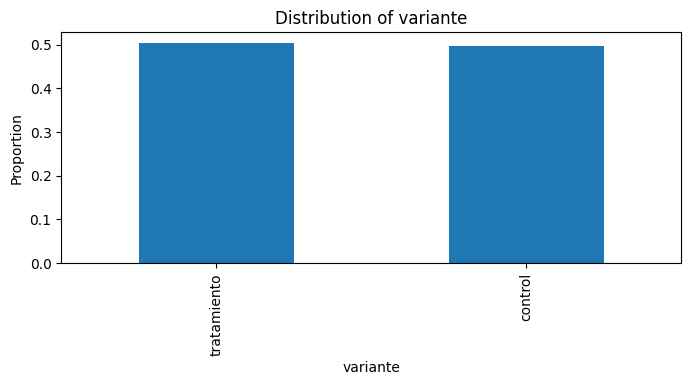

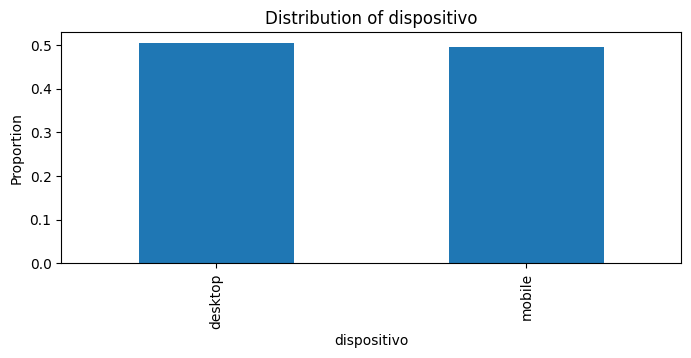

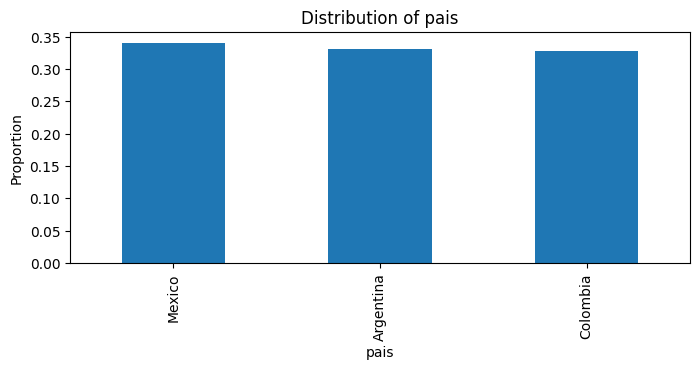

In [84]:
#Check the population of categorical variables
for col in ["variante","dispositivo","pais"]:
    proporciones=experimento[col].value_counts(normalize=True)

    plt.figure(figsize=(8, 3))
    proporciones.plot(kind="bar")
    plt.title(f"Distribution of {col}")
    plt.ylabel("Proportion")
    plt.xlabel(col)
    plt.show()



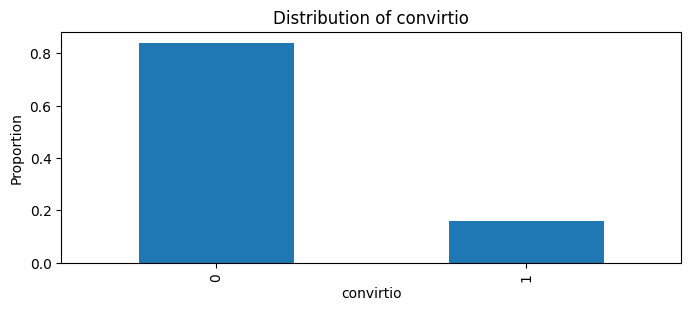

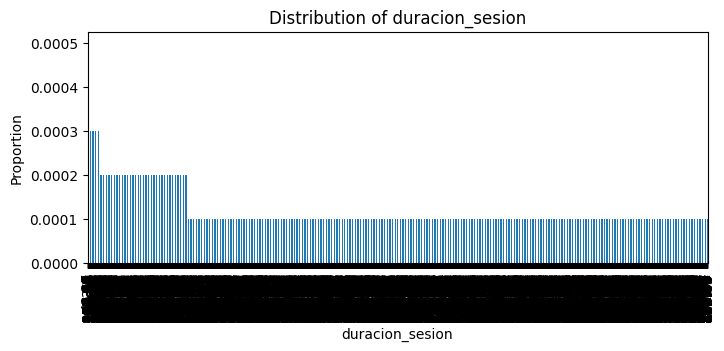

In [85]:
#Check the population of numeric variables
for col in ["convirtio","duracion_sesion"]:
    proporciones_num=experimento[col].value_counts(normalize=True)

    plt.figure(figsize=(8, 3))
    proporciones_num.plot(kind="bar")
    plt.title(f"Distribution of {col}")
    plt.ylabel("Proportion")
    plt.xlabel(col)
    plt.show()

In [86]:
#Calculate conversion rates (control and treatment)

#split the dataset by variant
grupo_control = experimento[experimento["variante"] == "control"]
grupo_tratamiento = experimento[experimento["variante"] == "tratamiento"]
#get the size of each group
n_c, n_t = len(grupo_control), len(grupo_tratamiento)
#count how many conversions each group had
conv_c, conv_t = grupo_control["convirtio"].sum(), grupo_tratamiento["convirtio"].sum()
#calculate conversion rates for control and treatment
tasa_c, tasa_t = conv_c / n_c, conv_t / n_t

print(f"\nControl:     {conv_c} conversions out of {n_c} users -> conversion rate:  {tasa_c*100:.2f}%")
print(f"Treatment: {conv_t} conversions out of {n_t} users -> conversion rate: {tasa_t*100:.2f}%")



Control:     779 conversions out of 4965 users -> conversion rate:  15.69%
Treatment: 820 conversions out of 5035 users -> conversion rate: 16.29%


In [87]:
#Apply Z-test
from statsmodels.stats.proportion import proportions_ztest

# Pass values as a list
exitos = [conv_c, conv_t]
observaciones = [n_c,n_t]

#Apply the test and view results
z_stat, p_value = proportions_ztest(exitos , observaciones)
print(f"Z statistic: {z_stat}")
print(f"P-value: {p_value}")

# Interpret results
alpha = 0.05  # significance threshold
if p_value < alpha:
    print("We reject the null hypothesis: there is evidence of a difference.")
else:
    print("We fail to reject the null hypothesis: there is not enough evidence of a difference.")



Z statistic: -0.8132782986429474
P-value: 0.41605851639119995
We fail to reject the null hypothesis: there is not enough evidence of a difference.


**Conclusion:** The Z-test produced a statistic of z = -0.813 and a p-value = 0.4161, higher than the established significance level (α = 0.05). Therefore, **H₀ is not rejected**, and there is no statistically significant evidence to claim that the modified checkout UI generates a higher conversion rate than the current UI.

Although there may be an observed difference between the two versions, **this difference is not large enough from a statistical standpoint** to conclude that the new UI improves conversion. With the available data, the design change does not demonstrate a clear benefit over the current version.

**Recommendation:** Do not implement the new UI based solely on this test. If the change has strategic interest, it is recommended to run a new test over a longer period. It would also be worth analyzing other checkout indicators, such as abandonment, completion time, or errors, to determine whether the new interface brings improvements even if it doesn't significantly increase conversion.

---

## 🔹 Step 6: Communicate the results (BI Dashboard)

🎯 **Objective**:  
Create a dashboard that clearly and visually shows the results of the sales, cost, marketing, and conversion analysis.

The clean CSVs from Step 1 will be used:

- `orders_clean.csv`  
- `catalog_clean.csv`  
- `marketing_clean.csv`

---

1️⃣ Data preparation
1. Load the CSVs into Power BI
2. Review relationships:

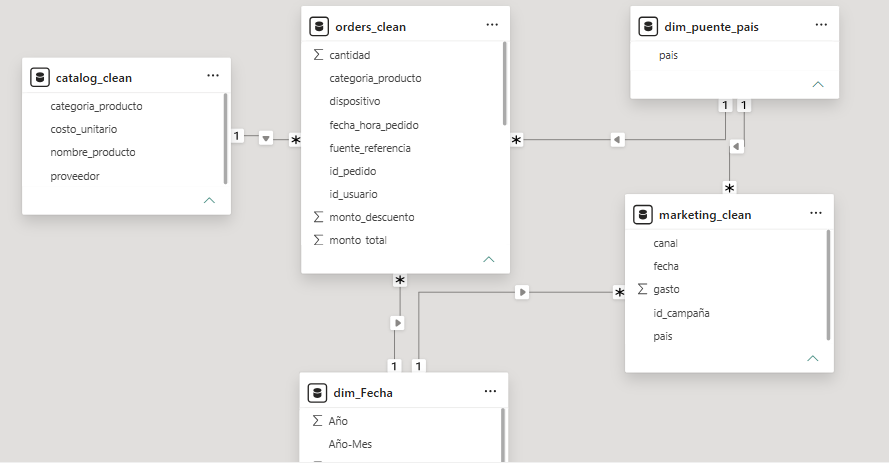


---

### 📎 Dashboard Link


https://drive.google.com/drive/folders/18Z5Tzot72NF3Jxzcu2OroR-UOnMWOPjr?usp=sharing